In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from torch.utils.data import DataLoader, Dataset
from rdkit.Chem import AllChem

In [2]:
# --------------------
# 1️⃣ Dataset Preparation (ZINC15 for FLPs)
# --------------------
class ZINC15Dataset(Dataset):
    def __init__(self, smiles_list):
        self.smiles = smiles_list
        self.fingerprints = [self.smiles_to_fp(smile) for smile in self.smiles]
    
    def smiles_to_fp(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024))
        else:
            return np.zeros(1024)
    
    def __len__(self):
        return len(self.fingerprints)
    
    def __getitem__(self, idx):
        return torch.tensor(self.fingerprints[idx], dtype=torch.float32)

In [3]:
# Load dataset (Replace with actual ZINC15 FLP subset)
zinc15_smiles = ["CCOC(=O)C1=CC=CC=C1", "CCC(=O)OCC", "CCCCCCCC"]  # Placeholder
zinc15_dataset = ZINC15Dataset(zinc15_smiles)
data_loader = DataLoader(zinc15_dataset, batch_size=64, shuffle=True)

[15:50:36] DEPRECATION WARNING: please use MorganGenerator
[15:50:36] DEPRECATION WARNING: please use MorganGenerator
[15:50:36] DEPRECATION WARNING: please use MorganGenerator


In [4]:
# --------------------
# 2️⃣ WGAN-GP Architecture
# --------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)

In [5]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.model(x)

In [6]:
# Initialize models
generator = Generator(latent_dim=128, output_dim=1024)
discriminator = Discriminator(input_dim=1024)

def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)
    alpha = alpha.expand_as(real_samples)
    interpolates = alpha * real_samples + ((1 - alpha) * fake_samples)
    interpolates.requires_grad_(True)
    d_interpolates = D(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Epoch 0, Loss D: 8.148442268371582, Loss G: 0.011166970245540142


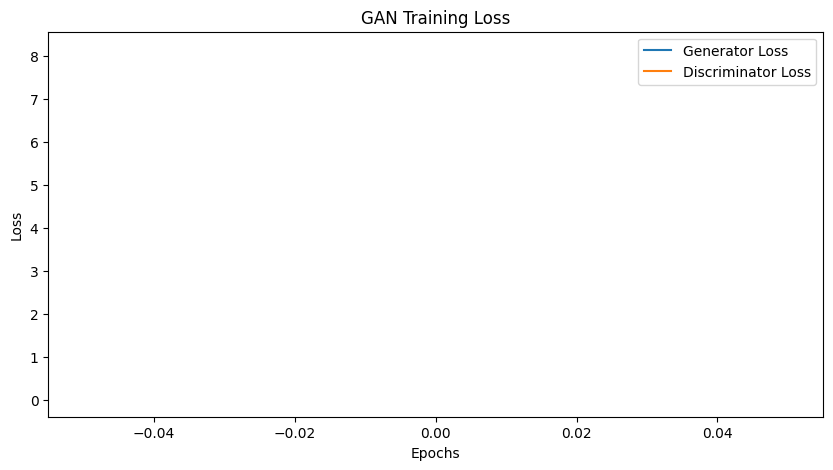

Epoch 500, Loss D: -1.6788924932479858, Loss G: 0.3400789201259613


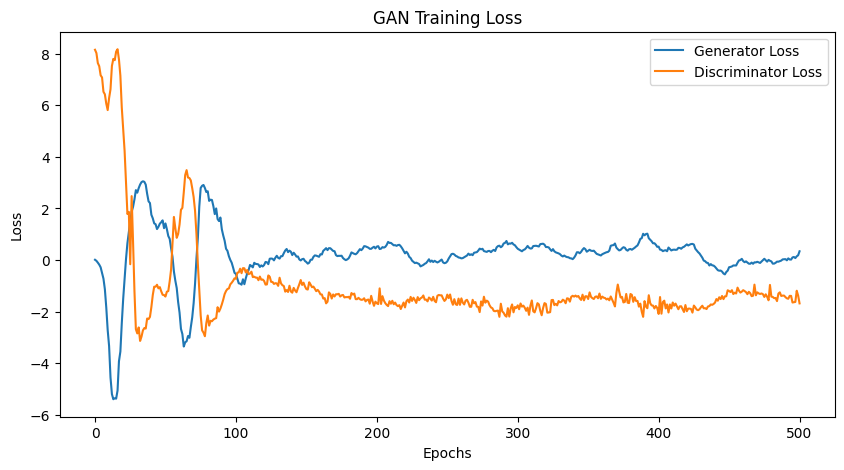

Epoch 1000, Loss D: -2.1977345943450928, Loss G: 0.1723354607820511


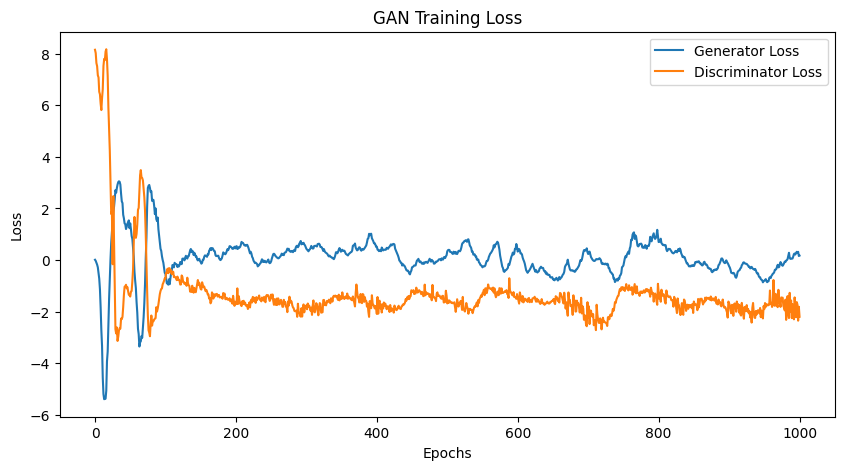

Epoch 1500, Loss D: -1.0858924388885498, Loss G: 0.45831605792045593


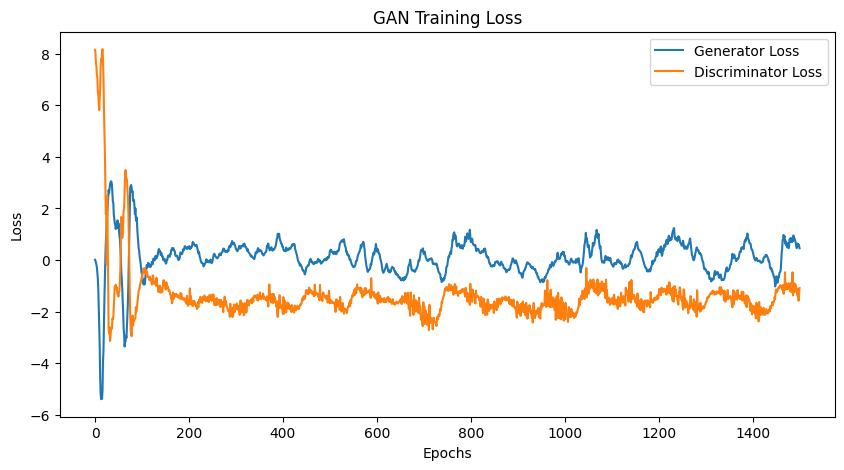

Epoch 2000, Loss D: -1.4176037311553955, Loss G: -0.40498384833335876


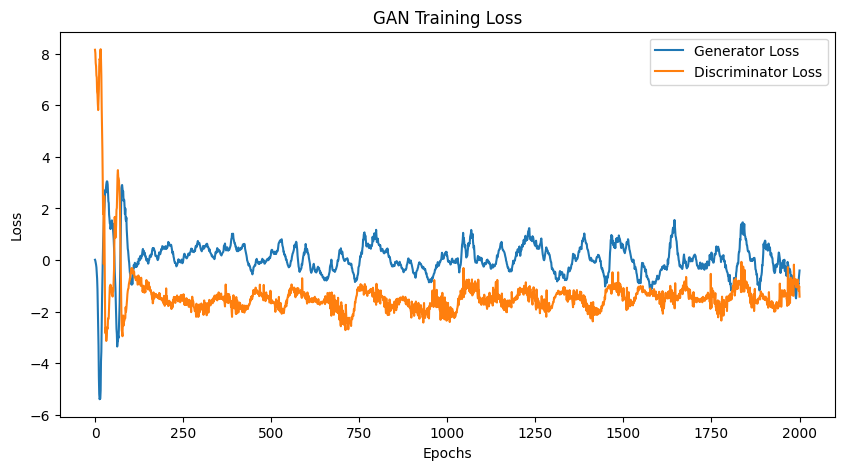

Epoch 2500, Loss D: -1.0763508081436157, Loss G: -0.2502952814102173


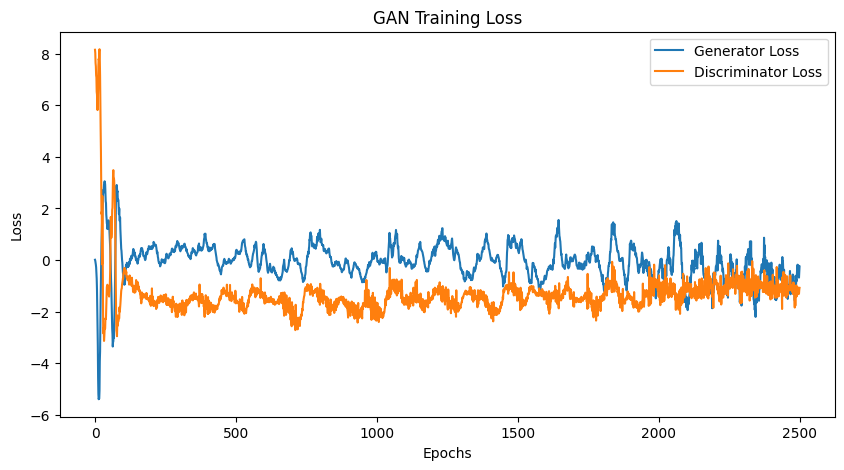

Epoch 3000, Loss D: -1.232358694076538, Loss G: -0.9817317128181458


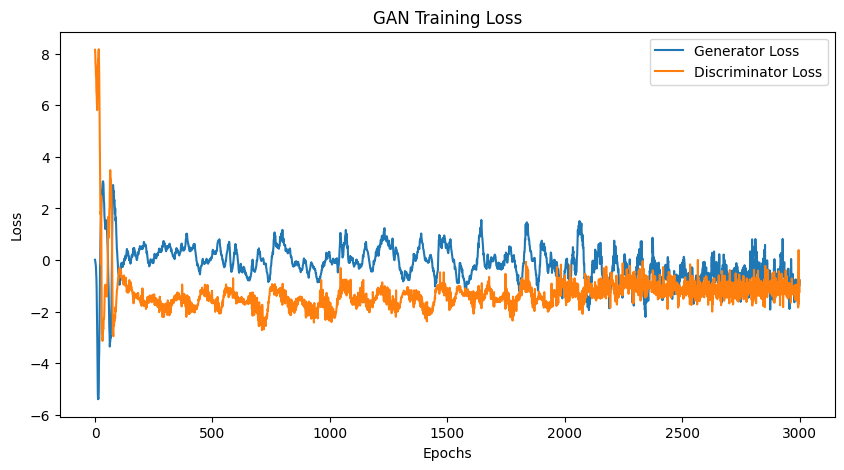

Epoch 3500, Loss D: -1.1558163166046143, Loss G: -1.2245726585388184


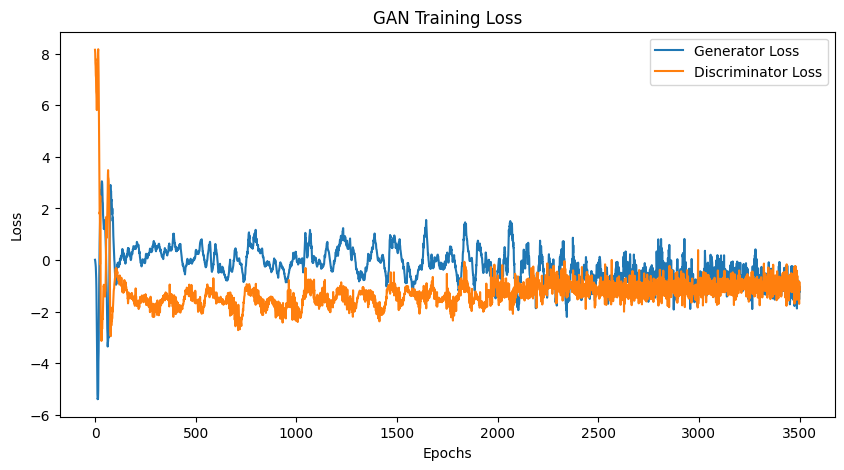

Epoch 4000, Loss D: -1.3383588790893555, Loss G: -1.1755465269088745


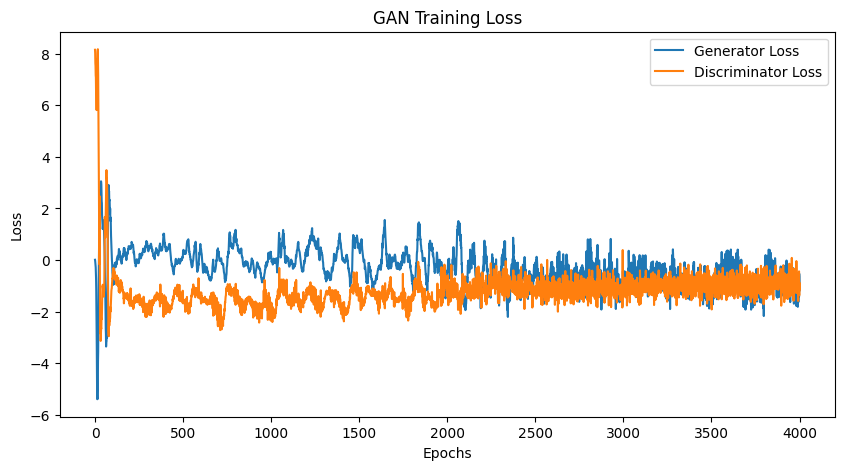

Epoch 4500, Loss D: -0.7514153718948364, Loss G: -1.3123387098312378


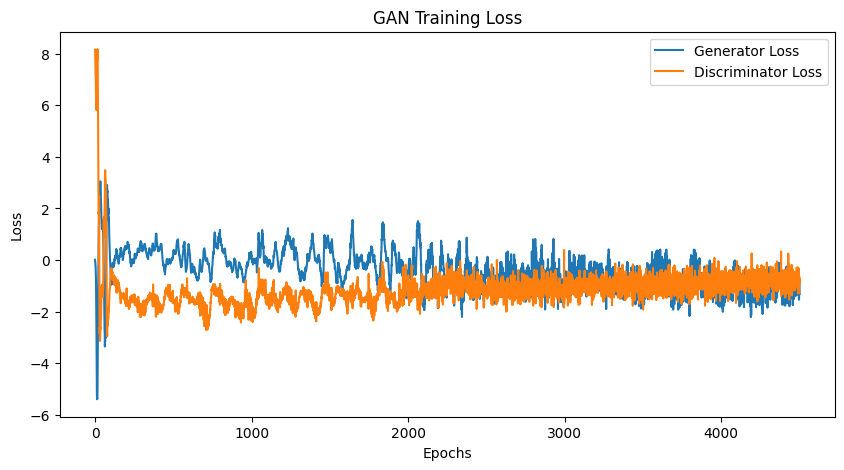

Epoch 5000, Loss D: -1.292102336883545, Loss G: -1.00639009475708


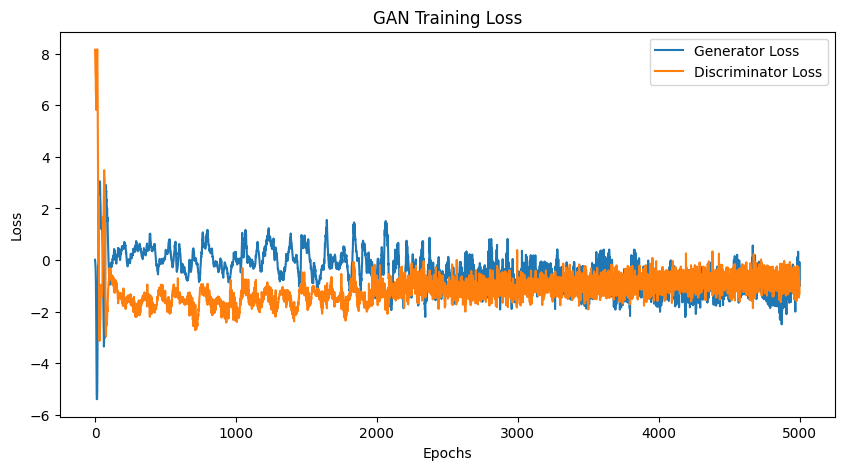

Epoch 5500, Loss D: -0.6632678508758545, Loss G: -1.3863835334777832


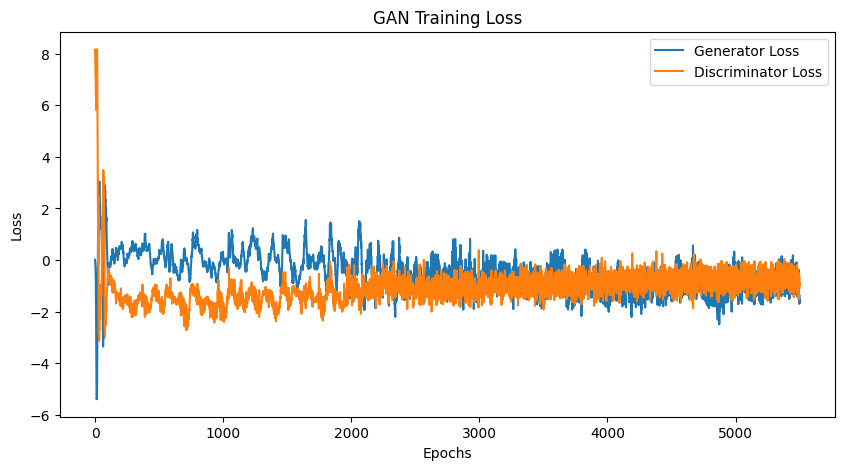

Epoch 6000, Loss D: -0.397493451833725, Loss G: -1.642351746559143


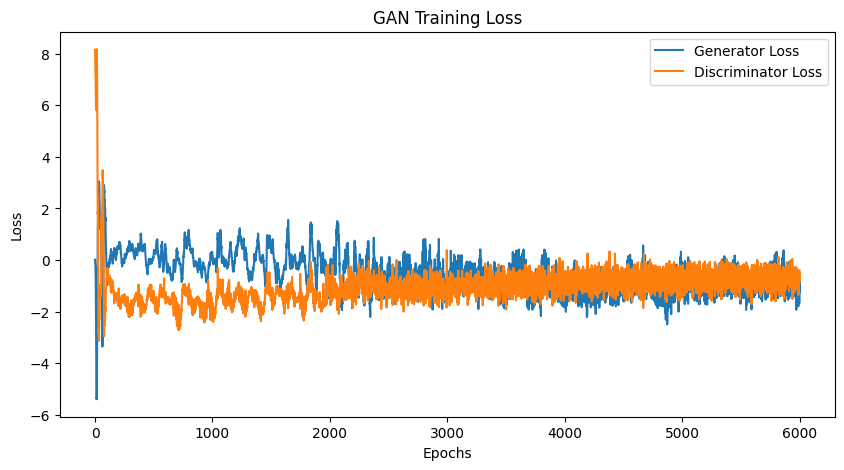

Epoch 6500, Loss D: -0.4239627718925476, Loss G: -0.8742124438285828


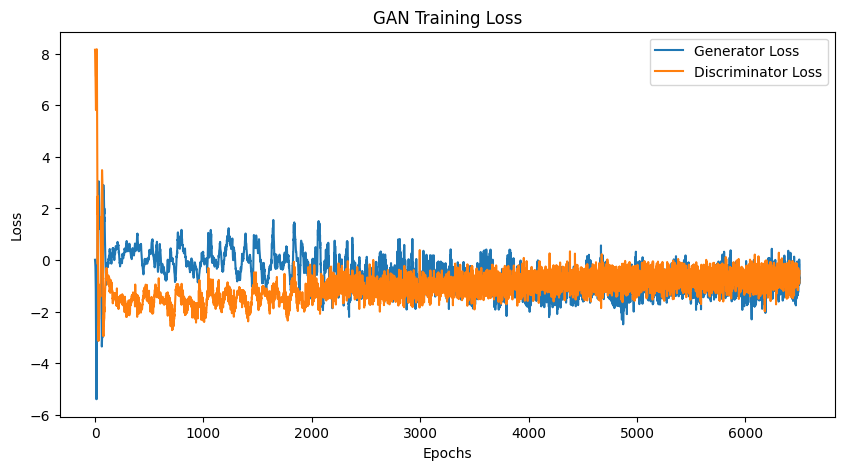

Epoch 7000, Loss D: -0.21735665202140808, Loss G: -0.8683434128761292


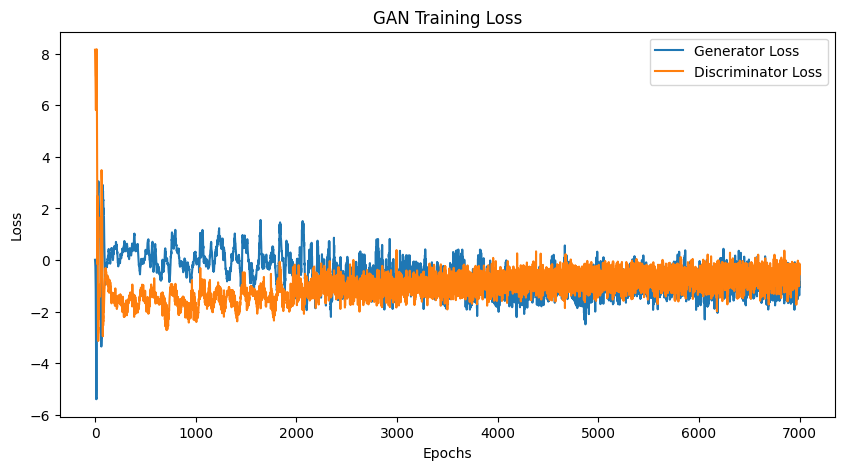

Epoch 7500, Loss D: -0.1673617660999298, Loss G: -1.2546297311782837


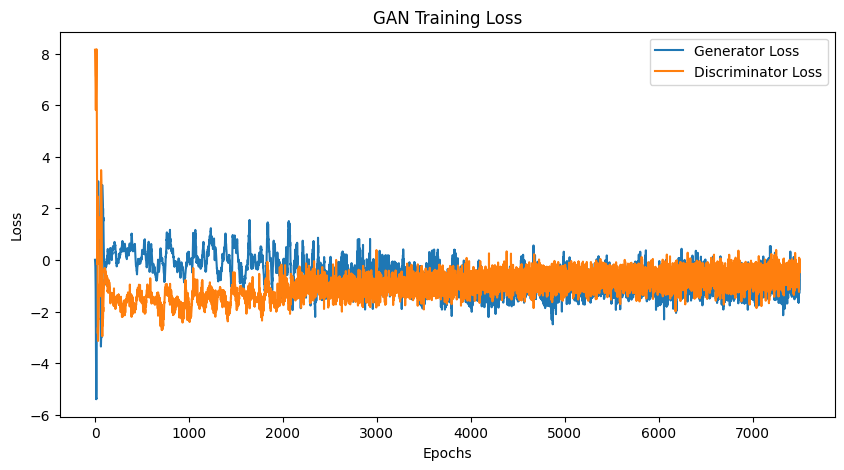

Epoch 8000, Loss D: -0.3485463261604309, Loss G: -1.1642711162567139


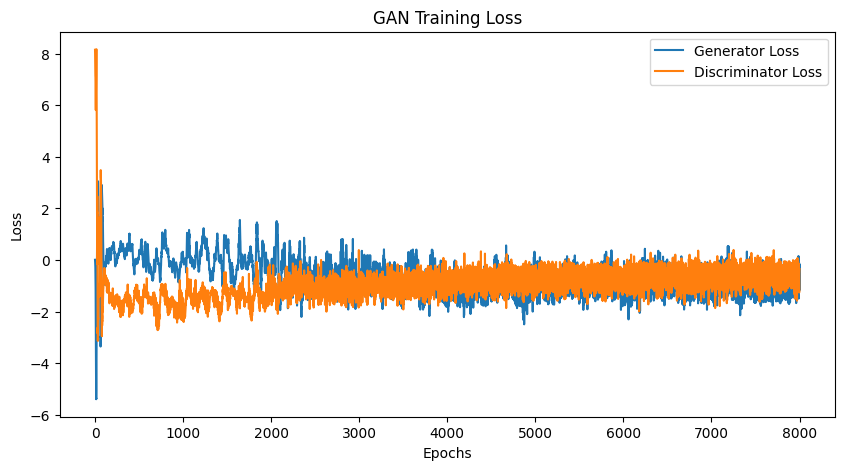

Epoch 8500, Loss D: -1.0663037300109863, Loss G: -0.7340114116668701


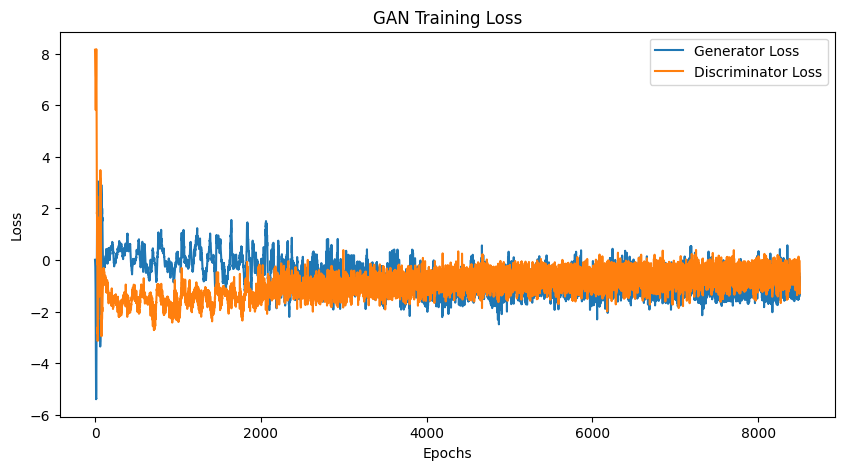

Epoch 9000, Loss D: -1.1420108079910278, Loss G: -1.388278603553772


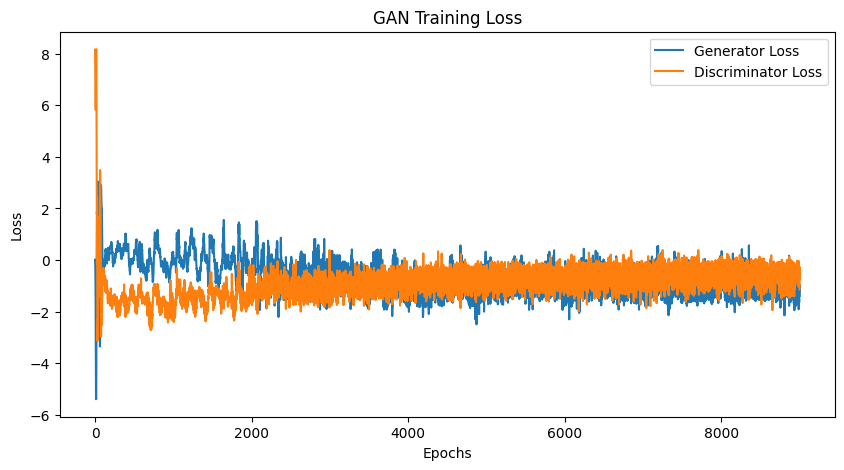

Epoch 9500, Loss D: -1.3567742109298706, Loss G: -1.1591545343399048


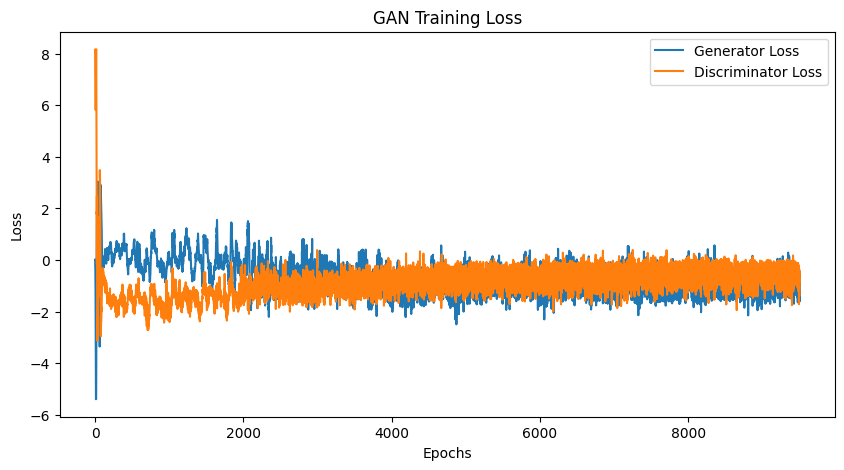

In [7]:
# --------------------
# 3️⃣ Training Loop (WGAN-GP)
# --------------------
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.9))

n_epochs = 10000
lambda_gp = 10
losses_G, losses_D = [], []

def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()

for epoch in range(n_epochs):
    for real_samples in data_loader:
        real_samples = real_samples.float()
        batch_size = real_samples.size(0)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        z = torch.randn(batch_size, 128)
        fake_samples = generator(z).detach()
        loss_D_real = -torch.mean(discriminator(real_samples))
        loss_D_fake = torch.mean(discriminator(fake_samples))
        gradient_penalty = compute_gradient_penalty(discriminator, real_samples, fake_samples)
        loss_D = loss_D_real + loss_D_fake + lambda_gp * gradient_penalty
        loss_D.backward()
        optimizer_D.step()
        
        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, 128)
        fake_samples = generator(z)
        loss_G = -torch.mean(discriminator(fake_samples))
        loss_G.backward()
        optimizer_G.step()
        
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")
        plot_losses()

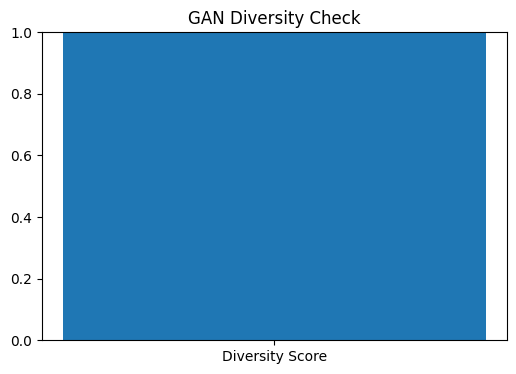

In [9]:
# --------------------
# 4️⃣ Diversity & Uniqueness Checks
# --------------------
def calculate_diversity(samples):
    unique_samples = set(tuple(sample) for sample in samples)
    return len(unique_samples) / len(samples) if len(samples) > 0 else 0  # Prevent zero division

def plot_diversity():
    z = torch.randn(1000, 128)
    generated_samples = generator(z).detach().numpy()
    diversity_score = calculate_diversity(generated_samples)

    plt.figure(figsize=(6, 4))
    plt.bar(['Diversity Score'], [diversity_score])
    plt.ylim(0, 1)
    plt.title('GAN Diversity Check')
    plt.show()

plot_diversity()

In [10]:
# --------------------
# 4️⃣ Validity & Fuel Property Checks (RDKit)
# --------------------
def evaluate_fuel_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            "Validity": True,
            "Energy Density": Descriptors.MolWt(mol),  # Placeholder, actual energy density is complex
            "Stability": rdMolDescriptors.CalcNumRotatableBonds(mol) < 5,
            "Combustion Efficiency": Descriptors.TPSA(mol)  # Proxy metric
        }
    return {"Validity": False}

z = torch.randn(10, 128)
generated_molecules = generator(z).detach().numpy()
smiles_list = ["CCOC(=O)C1=CC=CC=C1", "CCC(=O)OCC"]  # Convert generated vectors to SMILES (mock data)

for smi in smiles_list:
    print(evaluate_fuel_properties(smi))

{'Validity': True, 'Energy Density': 150.177, 'Stability': True, 'Combustion Efficiency': 26.3}
{'Validity': True, 'Energy Density': 102.133, 'Stability': True, 'Combustion Efficiency': 26.3}
